In [ ]:
# ============================================================
# KLASIFIKASI PENYAKIT KAKAO: CNN-ViT Hybrid dengan EfficientNetB0
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================
# CELL 2: Install & Import
# ==========================
# !pip install -q tensorflow==2.13.0 scikit-learn matplotlib seaborn opencv-python

import os, gc, random, shutil, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score,
                              accuracy_score)
from sklearn.utils import resample
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: []


In [ ]:
# ==========================
# CELL 3: Konfigurasi Path & Hyperparameter
# ==========================
BASE_DIR     = '/content/drive/MyDrive/split'   # <-- ubah ini
TRAIN_DIR    = os.path.join(BASE_DIR, 'train')
VALID_DIR    = os.path.join(BASE_DIR, 'valid')
TEST_DIR     = os.path.join(BASE_DIR, 'test')

CKPT_DIR     = '/content/drive/MyDrive/kakao_checkpoint_inbalanceddata'
CKPT_PATH    = os.path.join(CKPT_DIR, 'best_model.keras')
CKPT_FT_PATH = os.path.join(CKPT_DIR, 'best_model_finetune.keras')
EPOCH_LOG    = os.path.join(CKPT_DIR, 'epoch_log.json')
HISTORY_LOG  = os.path.join(CKPT_DIR, 'history_log.json')

os.makedirs(CKPT_DIR, exist_ok=True)

CLASS_NAMES     = sorted(os.listdir(TRAIN_DIR))
IMG_SIZE        = 224
BATCH_SIZE      = 16
EPOCHS          = 50
FINETUNE_EPOCHS = 20
N_CLASSES       = len(CLASS_NAMES)
TARGET_TOTAL    = 750
LR              = 1e-4

print("Kelas:", CLASS_NAMES)
print(f"Jumlah kelas terdeteksi: {len(CLASS_NAMES)}")

Kelas: ['black pod rot', 'healthy', 'helopeltis', 'mealybugs', 'mirid', 'monilia perniciosa (witches broom)', 'moniliophthora roreri (monilia)', 'pod borer']
Jumlah kelas terdeteksi: 8


In [ ]:
# ==========================
# CELL 4: Analisis Distribusi Dataset Awal
# ==========================
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        path = os.path.join(directory, cls)
        if os.path.isdir(path):
            counts[cls] = len([f for f in os.listdir(path)
                                if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return counts

train_counts = count_images(TRAIN_DIR)
print("\nDistribusi TRAIN (sebelum balancing):")
for k, v in train_counts.items():
    print(f"  {k}: {v}")


Distribusi TRAIN (sebelum balancing):
  black pod rot: 660
  healthy: 2340
  helopeltis: 350
  mealybugs: 314
  mirid: 229
  monilia perniciosa (witches broom): 67
  moniliophthora roreri (monilia): 245
  pod borer: 350


In [ ]:
# ==========================
# CELL 6: Data Generator
# ==========================
train_datagen = ImageDataGenerator()
val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True, seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    VALID_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print(f"\nTrain steps/epoch : {len(train_gen)}")
print(f"Val   steps/epoch : {len(val_gen)}")
print(f"Test  steps       : {len(test_gen)}")

Found 4555 images belonging to 8 classes.
Found 976 images belonging to 8 classes.
Found 980 images belonging to 8 classes.

Train steps/epoch : 285
Val   steps/epoch : 61
Test  steps       : 62


In [ ]:
# ==========================
# CELL 7: CBAM Attention — FIXED
# ==========================
# [FIX 1] Sub-layer Dense/Reshape/Multiply diinisialisasi di build(), bukan call()
# [FIX 2] Ganti keras.ops → tf.reduce_*  (TF 2.13 belum punya keras.ops)

class ChannelAttention(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        c = input_shape[-1]
        self.gap = layers.GlobalAveragePooling2D()
        self.gmp = layers.GlobalMaxPooling2D()
        self.dense1 = layers.Dense(c // self.ratio, activation='relu', use_bias=False)
        self.dense2 = layers.Dense(c, activation='sigmoid', use_bias=False)
        super().build(input_shape)

    def call(self, x):
        c = tf.shape(x)[-1]
        avg_out = self.dense2(self.dense1(self.gap(x)))   # (B, C)
        max_out = self.dense2(self.dense1(self.gmp(x)))
        out = avg_out + max_out                            # element-wise add
        out = tf.reshape(out, (-1, 1, 1, tf.shape(out)[-1]))
        return x * out


class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = layers.Conv2D(1, self.kernel_size, padding='same',
                                   activation='sigmoid')
        super().build(input_shape)

    def call(self, x):
        # [FIX 2] tf.reduce_mean/max menggantikan keras.ops.mean/max
        avg_out = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_out = tf.reduce_max(x,  axis=-1, keepdims=True)
        concat  = tf.concat([avg_out, max_out], axis=-1)
        out     = self.conv(concat)
        return x * out


class CBAMBlock(layers.Layer):
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ch_attn = ChannelAttention(ratio)
        self.sp_attn = SpatialAttention(kernel_size)

    def call(self, x):
        x = self.ch_attn(x)
        x = self.sp_attn(x)
        return x

In [ ]:
# ==========================
# CELL 8: Positional Encoding
# ==========================
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model

    def build(self, input_shape):
        initializer = tf.keras.initializers.RandomNormal(stddev=0.02)
        self.pos_emb = self.add_weight(
            shape=(1, self.seq_len, self.d_model),
            initializer='random_normal', trainable=True, name='pos_enc'
        )

    def call(self, x):
        return x + self.pos_emb

In [ ]:
# ==========================
# CELL 9: Transformer Encoder
# ==========================
def transformer_encoder(x, num_heads=8, ff_dim=512, dropout=0.1):
    d_model = x.shape[-1]
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout
    )(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    ffn = layers.Dense(ff_dim, activation='gelu')(x)
    ffn = layers.Dropout(dropout)(ffn)
    ffn = layers.Dense(d_model)(ffn)
    ffn = layers.Dropout(dropout)(ffn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)
    return x

In [ ]:
# ==========================
# CELL 10: Attention Pooling
# ==========================
class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.score_dense = layers.Dense(1)
        super().build(input_shape)

    def call(self, x):
        scores  = self.score_dense(x)              # (B, seq, 1)
        weights = tf.nn.softmax(scores, axis=1)
        out     = tf.reduce_sum(x * weights, axis=1)   # (B, d_model)
        return out

In [ ]:
# ==========================
# CELL 11: Build CNN-ViT Model — FIXED
# ==========================
# [FIX] Ganti input_tensor=inputs → inputs=inputs agar EfficientNetB0
#       terbungkus sebagai sub-model bernama 'efficientnetb0',
#       sehingga model.get_layer('efficientnetb0') bisa bekerja di Cell 17.

tf.keras.backend.clear_session()
gc.collect()

def build_cnn_vit(img_size=224, n_classes=8):
    inputs = keras.Input(shape=(img_size, img_size, 3))

    # ── 1. Backbone EfficientNetB0 ──
    # Gunakan inputs= (bukan input_tensor=) agar backbone terbungkus
    # sebagai named sub-model, bukan di-inline ke dalam model utama
    backbone = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)   # ← ganti input_tensor → input_shape
    )
    backbone.trainable = False
    feat_map = backbone(inputs, training=False)               # ← panggil sebagai sub-model

    # ── 2. CBAM Attention ──
    feat_map = CBAMBlock()(feat_map)

    # ── 3. Konversi Feature Map → Token Sequence ──
    H = feat_map.shape[1]
    W = feat_map.shape[2]
    C = feat_map.shape[3]
    seq_len = H * W
    d_model = 256

    x = layers.Reshape((seq_len, C))(feat_map)
    x = layers.Dense(d_model)(x)
    x = PositionalEncoding(seq_len, d_model)(x)
    x = transformer_encoder(x, num_heads=8, ff_dim=512, dropout=0.1)
    x = transformer_encoder(x, num_heads=8, ff_dim=512, dropout=0.1)
    x = AttentionPooling()(x)

    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='CNN_ViT_Kakao')
    return model

model = build_cnn_vit(IMG_SIZE, N_CLASSES)
model.summary()

# Verifikasi backbone bisa diakses sebelum lanjut
try:
    _ = model.get_layer('efficientnetb0')
    print("✅ Backbone 'efficientnetb0' ditemukan sebagai sub-model.")
except ValueError as e:
    print(f"❌ {e}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CNN_ViT_Kakao"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_block          │ (None, 7, 7,      │    409,699 │ efficientnetb0[0… │
│ (CBAMBlock)         │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 49, 1280)  │          0 │ cbam_block[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 49, 256)   │    327,936 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 49, 256)   │     12,544 │ dense_2[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 256)   │    263,168 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 49, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 256)   │          0 │ positional_encod… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 49, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 49, 512)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 49, 256)   │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 49, 256)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 49, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 49, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,953,935 (22.71 MB)

 Trainable params: 1,904,364 (7.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

✅ Backbone 'efficientnetb0' ditemukan sebagai sub-model.


In [ ]:
# ==========================
# CELL 12: Compile Model
# ==========================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ==========================
# CELL 14: Resume Otomatis dari Checkpoint (Anti-Error)
# ==========================
def load_epoch_log():
    if os.path.exists(EPOCH_LOG):
        with open(EPOCH_LOG) as f:
            return json.load(f)
    return {"stage": "pretrain", "epoch": 0}

def save_epoch_log(stage, epoch):
    with open(EPOCH_LOG, 'w') as f:
        json.dump({"stage": stage, "epoch": epoch}, f)

def load_history_log():
    if os.path.exists(HISTORY_LOG):
        with open(HISTORY_LOG) as f:
            return json.load(f)
    return {}

def save_history_log(hist_dict):
    with open(HISTORY_LOG, 'w') as f:
        json.dump(hist_dict, f)

# ── FIX: Beri nilai default agar tidak terjadi NameError ──
INITIAL_EPOCH = 0
INITIAL_EPOCH_FT = 0

epoch_log = load_epoch_log()
print(f"Status checkpoint: stage={epoch_log['stage']}, epoch={epoch_log['epoch']}")

if epoch_log['stage'] == 'finetune':
    STAGE = 'finetune'
    INITIAL_EPOCH_FT = epoch_log['epoch']

    if os.path.exists(CKPT_FT_PATH):
        print("Melanjutkan dari checkpoint fine-tune...")
        model.load_weights(CKPT_FT_PATH)
    elif os.path.exists(CKPT_PATH):
        print("Memulai fase fine-tune dari model pretrain terbaik...")
        model.load_weights(CKPT_PATH)

elif os.path.exists(CKPT_PATH):
    print("Melanjutkan dari checkpoint pretrain...")
    model.load_weights(CKPT_PATH)
    STAGE = 'pretrain'
    INITIAL_EPOCH = epoch_log['epoch']
else:
    print("Tidak ada checkpoint. Training dari awal.")
    STAGE = 'pretrain'

Status checkpoint: stage=finetune, epoch=20
Melanjutkan dari checkpoint fine-tune...


In [ ]:
# ==========================
# CELL 15: Callbacks Helper
# ==========================
class EpochLogger(keras.callbacks.Callback):
    """Simpan epoch terakhir ke disk setiap akhir epoch."""
    def __init__(self, stage):
        super().__init__()
        self.stage = stage
    def on_epoch_end(self, epoch, logs=None):
        save_epoch_log(self.stage, epoch + 1)

In [ ]:
# ==========================
# CELL 16: Training Tahap 1 — Backbone Frozen
# ==========================
if STAGE == 'pretrain':
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=7,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=1),
        ModelCheckpoint(CKPT_PATH, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        EpochLogger('pretrain'),  # [NEW]
    ]

    history = model.fit(
        train_gen,
        steps_per_epoch=len(train_gen),
        validation_steps=len(val_gen),
        validation_data=val_gen,
        epochs=EPOCHS,
        initial_epoch=INITIAL_EPOCH,
        callbacks=callbacks, # [FIX 3]
        verbose=1
    )

    # [FIX 7] Simpan history ke disk agar tidak hilang saat disconnect
    hist_dict = load_history_log()
    hist_dict['pretrain'] = history.history
    save_history_log(hist_dict)

    save_epoch_log('finetune', 0)  # tandai siap masuk fase fine-tune
    STAGE = 'finetune'
    INITIAL_EPOCH_FT = 0
else:
    print("Stage pretrain sudah selesai, melewati...")
    history = None

Epoch 1/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5985 - loss: 1.1259
Epoch 1: val_accuracy improved from None to 0.85656, saving model to /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 1096s 4s/step - accuracy: 0.7175 - loss: 0.8071 - val_accuracy: 0.8566 - val_loss: 0.4206 - learning_rate: 1.0000e-04
Epoch 2/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8553 - loss: 0.4152
Epoch 2: val_accuracy improved from 0.85656 to 0.90881, saving model to /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.8729 - loss: 0.3740 - val_accuracy: 0.9088 - val_loss: 0.2722 - learning_rate: 1.0000e-04
Epoch 3/50
285/285 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# ==========================
# CELL 17: Fine-Tuning — FIXED
# ==========================
# [FIX] Akses backbone via model.get_layer('efficientnetb0') sekarang bekerja
#       karena Cell 11 sudah menggunakan input_shape + backbone(inputs)

backbone_layer = model.get_layer('efficientnetb0')

# Freeze semua kecuali 20 layer terakhir
for layer in backbone_layer.layers[:-20]:
    layer.trainable = False
for layer in backbone_layer.layers[-20:]:
    layer.trainable = True

# Hitung berapa layer yang trainable sekarang
trainable_count = sum(1 for l in backbone_layer.layers if l.trainable)
print(f"Backbone trainable layers: {trainable_count} / {len(backbone_layer.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint(CKPT_FT_PATH, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EpochLogger('finetune'),
]

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINETUNE_EPOCHS,
    initial_epoch=INITIAL_EPOCH_FT,
    callbacks=callbacks_ft,
    verbose=1
)

# Simpan history fine-tune
hist_dict = load_history_log()
hist_dict['finetune'] = history_ft.history
save_history_log(hist_dict)

Backbone trainable layers: 20 / 238
Epoch 1/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8746 - loss: 0.4158
Epoch 1: val_accuracy improved from None to 0.90676, saving model to /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model_finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model_finetune.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.8915 - loss: 0.3579 - val_accuracy: 0.9068 - val_loss: 0.3491 - learning_rate: 1.0000e-05
Epoch 2/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9282 - loss: 0.2349
Epoch 2: val_accuracy improved from 0.90676 to 0.91291, saving model to /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model_finetune.keras

Epoch 2: finished saving model to /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model_finetune.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 502s 2s/step - accuracy: 0.9326 - loss: 0.2175 - val_accuracy: 0.9129 - val_loss: 0.

In [ ]:
# ==========================
# CELL 18: Evaluasi Model
# ==========================
best_ckpt = CKPT_FT_PATH if os.path.exists(CKPT_FT_PATH) else CKPT_PATH
model.load_weights(best_ckpt)

test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

print("\n=== Evaluation Report ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_true, y_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

62/62 ━━━━━━━━━━━━━━━━━━━━ 270s 4s/step

=== Evaluation Report ===
Accuracy : 0.9173
Precision: 0.9164
Recall   : 0.9173
F1-Score : 0.9144

Classification Report:
                                    precision    recall  f1-score   support

                     black pod rot       0.88      0.69      0.77       142
                           healthy       0.92      0.97      0.94       502
                        helopeltis       0.90      0.97      0.94        75
                         mealybugs       0.96      0.99      0.97        68
                             mirid       0.93      0.86      0.90        50
monilia perniciosa (witches broom)       0.92      0.80      0.86        15
   moniliophthora roreri (monilia)       0.96      0.98      0.97        53
                         pod borer       0.92      0.87      0.89        75

                          accuracy                           0.92       980
                         macro avg       0.92      0.89      0.91       980

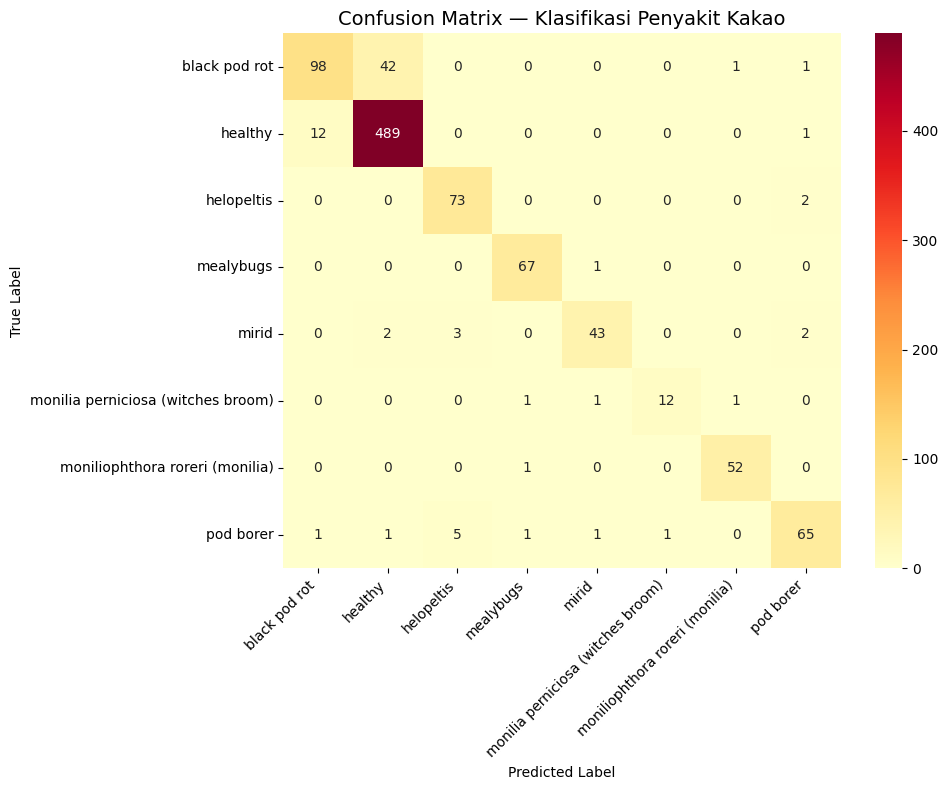

In [ ]:
# ==========================
# CELL 19: Confusion Matrix
# ==========================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Klasifikasi Penyakit Kakao', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

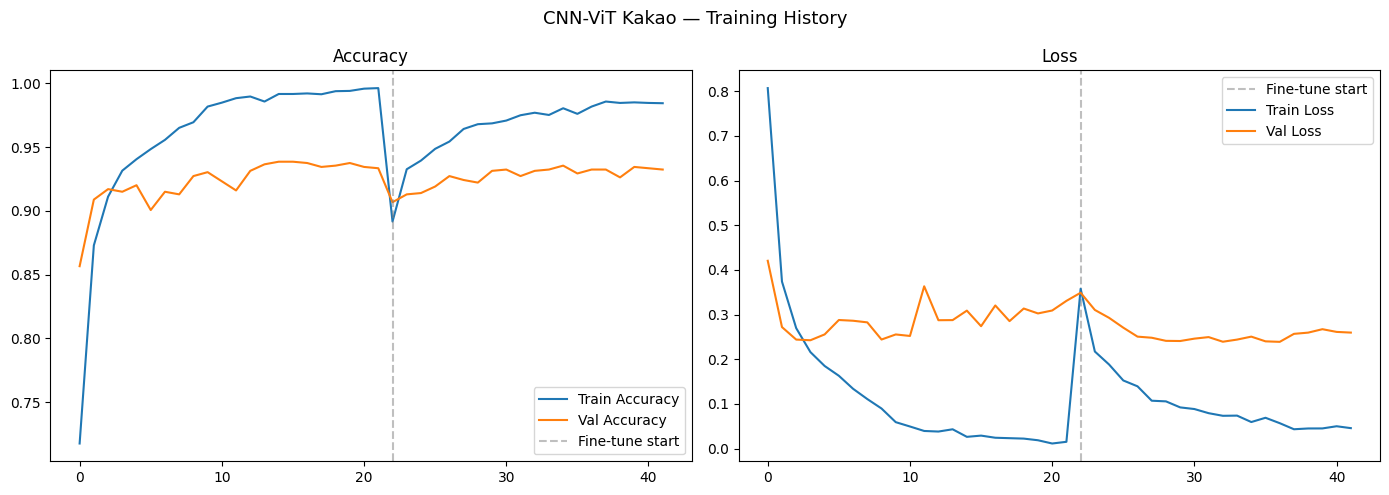


=== Analisis Overfitting/Underfitting ===
✅ Model generalisasi baik. Gap train-val = 5.20%.


In [ ]:
# ==========================
# CELL 20: Plot Training History — FIXED
# ==========================
# [FIX 7] Baca history dari disk sehingga bisa diplot meski resume dari disconnect

def plot_history_from_log(hist_log_path):
    hist_dict = load_history_log()
    acc, val_acc, loss, val_loss = [], [], [], []

    for stage in ['pretrain', 'finetune']:
        if stage in hist_dict:
            h = hist_dict[stage]
            acc      += h.get('accuracy', [])
            val_acc  += h.get('val_accuracy', [])
            loss     += h.get('loss', [])
            val_loss += h.get('val_loss', [])

    if not acc:
        print("History log kosong — tidak ada yang diplot.")
        return

    epochs_range = range(len(acc))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs_range, acc,     label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    if 'pretrain' in hist_dict and 'finetune' in hist_dict:
        split = len(hist_dict['pretrain'].get('accuracy', []))
        axes[0].axvline(split, color='gray', linestyle='--', alpha=0.5, label='Fine-tune start')
        axes[1].axvline(split, color='gray', linestyle='--', alpha=0.5, label='Fine-tune start')
    axes[0].set_title('Accuracy'); axes[0].legend()
    axes[1].plot(epochs_range, loss,     label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].set_title('Loss'); axes[1].legend()
    plt.suptitle('CNN-ViT Kakao — Training History', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'training_history.png'), dpi=150)
    plt.show()

    final_gap = abs(val_acc[-1] - acc[-1])
    print("\n=== Analisis Overfitting/Underfitting ===")
    if acc[-1] < 0.75 and val_acc[-1] < 0.75:
        print("⚠️  UNDERFITTING: Akurasi train & val rendah.")
    elif final_gap > 0.10:
        print(f"⚠️  OVERFITTING: Gap train-val = {final_gap:.2%}.")
    else:
        print(f"✅ Model generalisasi baik. Gap train-val = {final_gap:.2%}.")

plot_history_from_log(HISTORY_LOG)

[INFO] Grad-CAM Target Layer: cbam_block


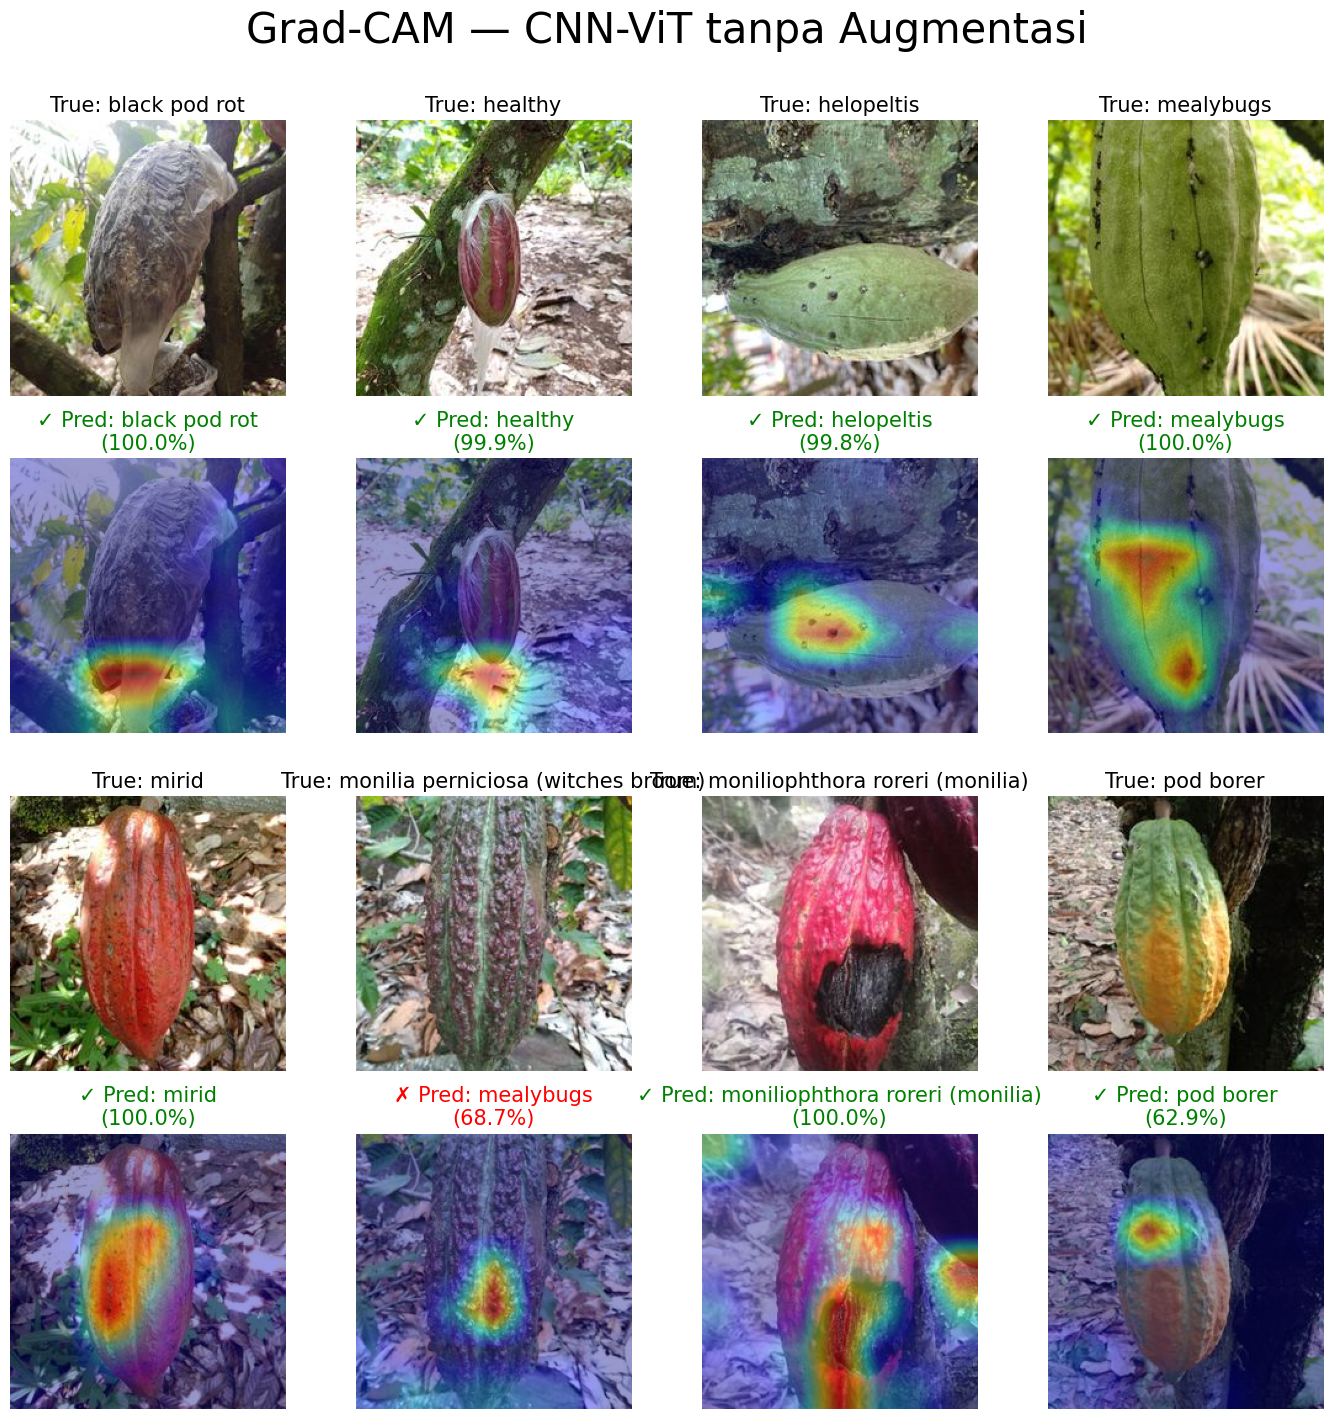

✅ Saved: /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/gradcam_sample_random.png


In [ ]:
# ==========================
# CELL 21: Grad-CAM — FIXED (Graph Connectivity & CBAM Target)
# ==========================
import matplotlib.cm as cm

def build_gradcam_model(model):
    # ── FIX: Cari layer CBAMBlock di outer model ──
    # Menghindari error graph terputus akibat nested model EfficientNetB0
    target_layer = None
    for layer in model.layers:
        if 'cbam' in layer.name.lower():
            target_layer = layer
            break

    # Fallback: Urutan layer di Cell 11 adalah (0: Input, 1: EffNet, 2: CBAM)
    if target_layer is None:
        target_layer = model.layers[2]

    print(f"[INFO] Grad-CAM Target Layer: {target_layer.name}")

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[target_layer.output, model.output],
        name='gradcam_model'
    )
    return grad_model


def make_gradcam_heatmap(img_array, grad_model, pred_index=None):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        feat_map, predictions = grad_model(img_tensor, training=False)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, feat_map)

    if grads is None:
        raise ValueError("Gradien None — Keras gagal melacak topologi graf.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = feat_map[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)

    heatmap_max = tf.math.reduce_max(heatmap)
    if heatmap_max != 0:
        heatmap = heatmap / heatmap_max

    return heatmap.numpy(), int(pred_index), predictions.numpy()[0]


def overlay_gradcam(img_input, heatmap, alpha=0.4):
    if isinstance(img_input, str):
        img = cv2.imread(img_input)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = np.uint8(np.clip(img_input, 0, 255))

    img             = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    return cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)


import random

def visualize_gradcam(model, test_gen, class_names, cols=4):
    grad_model = build_gradcam_model(model)

    n_samples = len(class_names)
    rows = (n_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows * 2, cols, figsize=(cols * 3.5, rows * 7))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    # ── LOGIKA BARU: Pilih 1 indeks gambar secara RANDOM untuk tiap kelas ──
    # 1. Kelompokkan semua nomor indeks gambar berdasarkan kelasnya
    class_indices = {i:[] for i in range(len(class_names))}
    for i, label in enumerate(test_gen.classes):
        class_indices[label].append(i)

    # 2. Pilih dari masing-masing kelas
    # chosen_indices = [random.choice(class_indices[i]) for i in range(len(class_names))]
    chosen_indices = [class_indices[i][0] for i in range(len(class_names))]

    # 3. Ambil gambar dari test_gen berdasarkan indeks yang terpilih tadi
    all_images = []
    all_labels =[]
    for idx in chosen_indices:
        batch_num = idx // test_gen.batch_size
        item_num  = idx % test_gen.batch_size

        batch_x, batch_y = test_gen[batch_num]

        all_images.append(batch_x[item_num])
        all_labels.append(np.argmax(batch_y[item_num]))

    # ── Proses Grad-CAM ──
    correct = 0
    for idx in range(n_samples):
        row_top = (idx // cols) * 2
        row_bot = row_top + 1
        col     = idx % cols

        img_array  = np.expand_dims(all_images[idx], axis=0)
        true_label = all_labels[idx]

        try:
            heatmap, pred_label, preds = make_gradcam_heatmap(img_array, grad_model)
            cam_img    = overlay_gradcam(all_images[idx], heatmap)
            confidence = float(preds[pred_label]) * 100
            cam_ok     = True

        except Exception as e:
            print(f"[WARN] Sampel {idx}: {e}")
            cam_img    = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            pred_label = 0
            confidence = 0.0
            cam_ok     = False

        is_correct = cam_ok and (pred_label == true_label)
        if is_correct:
            correct += 1

        axes[row_top][col].imshow(all_images[idx].astype('uint8'))
        axes[row_top][col].set_title(
            f"True: {class_names[true_label]}", fontsize=15)
        axes[row_top][col].axis('off')

        axes[row_bot][col].imshow(cam_img)
        color  = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        axes[row_bot][col].set_title(
            f"{status} Pred: {class_names[pred_label]}\n({confidence:.1f}%)",
            fontsize=15, color=color
        )
        axes[row_bot][col].axis('off')

    acc_sample = correct / n_samples * 100
    plt.suptitle(
        f'Grad-CAM — CNN-ViT tanpa Augmentasi',
        fontsize=30, y=1.01
    )
    plt.tight_layout()
    out_path = os.path.join(CKPT_DIR, 'gradcam_sample_random.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {out_path}")

# ── Panggil fungsinya:
visualize_gradcam(model, test_gen, CLASS_NAMES, cols=4)

In [ ]:
# ==========================
# CELL 22: Ringkasan Akhir
# ==========================
print("\n" + "="*55)
print("TRAINING SELESAI")
print("="*55)
print(f"Best pretrain checkpoint : {CKPT_PATH}")
print(f"Best fine-tune checkpoint: {CKPT_FT_PATH}")
print(f"Epoch log                : {EPOCH_LOG}")
print(f"History log              : {HISTORY_LOG}")
print(f"Confusion Matrix         : {CKPT_DIR}/confusion_matrix.png")
print(f"Training History         : {CKPT_DIR}/training_history.png")
print(f"Grad-CAM Sample          : {CKPT_DIR}/gradcam_sample.png")


TRAINING SELESAI
Best pretrain checkpoint : /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model.keras
Best fine-tune checkpoint: /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/best_model_finetune.keras
Epoch log                : /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/epoch_log.json
History log              : /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/history_log.json
Confusion Matrix         : /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/confusion_matrix.png
Training History         : /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/training_history.png
Grad-CAM Sample          : /content/drive/MyDrive/kakao_checkpoint_inbalanceddata/gradcam_sample.png
